# Random Forest Modeling

## 1. 라이브러리 로드
모델 학습, 평가, 데이터 처리 및 시각화를 위한 라이브러리를 불러온다.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    average_precision_score
)

from sklearn.ensemble import RandomForestClassifier

## 2. 데이터 불러오기
Netflix 사용자 데이터셋을 불러온다.

In [4]:
PROJECT_ROOT = '../../'

csv_path = os.path.join(
    PROJECT_ROOT,
    '00_data',
    '01_interim',
    'netflix_users_train.csv'
)

data_df = pd.read_csv(csv_path, low_memory=False)

print(data_df.shape)
data_df.head()

(8621, 18)


,user_id,age,plan_tier,is_active,monthly_spend,age_group,subscription_tenure_days,watch_count,unique_movies,total_watch_time,avg_watch_time,watch_days,recent_watch_count,days_since_last_watch,avg_progress,completion_rate,download_ratio,avg_rating
0,user_01621,55.0,1,1,11.17,5,527,20,19,859.5,42.975000,19,3.0,9,43.225000,0.100000,0.300000,3.714286
1,user_04521,40.0,1,0,7.13,4,695,7,7,528.0,75.428571,6,0.0,126,40.971429,0.000000,0.000000,0.000000
2,user_07927,64.0,2,1,35.39,6,378,14,14,660.1,47.150000,14,0.0,49,47.692857,0.071429,0.142857,3.000000
3,user_01217,52.0,3,1,7.62,5,319,12,12,832.7,69.391667,12,0.0,68,29.491667,0.083333,0.166667,3.000000
4,user_07125,33.0,1,0,60.98,3,510,13,12,709.6,54.584615,12,1.0,8,37.546154,0.153846,0.153846,3.000000


## 3. 타깃 정의 및 전처리
Churn 예측 목적에 맞게 `is_active`를 `is_churned`로 변환한다.

- is_active = 1 → churn = 0
- is_active = 0 → churn = 1

In [5]:
final_df = data_df.copy()

# user_id 제거
if 'user_id' in final_df.columns:
    final_df = final_df.drop(columns=['user_id'])

# churn 변수 생성
final_df['is_churned'] = 1 - final_df['is_active']

# 기존 변수 제거
final_df = final_df.drop(columns=['is_active'])

final_df.head()

,age,plan_tier,monthly_spend,age_group,subscription_tenure_days,watch_count,unique_movies,total_watch_time,avg_watch_time,watch_days,recent_watch_count,days_since_last_watch,avg_progress,completion_rate,download_ratio,avg_rating,is_churned
0,55.0,1,11.17,5,527,20,19,859.5,42.975000,19,3.0,9,43.225000,0.100000,0.300000,3.714286,0
1,40.0,1,7.13,4,695,7,7,528.0,75.428571,6,0.0,126,40.971429,0.000000,0.000000,0.000000,1
2,64.0,2,35.39,6,378,14,14,660.1,47.150000,14,0.0,49,47.692857,0.071429,0.142857,3.000000,0
3,52.0,3,7.62,5,319,12,12,832.7,69.391667,12,0.0,68,29.491667,0.083333,0.166667,3.000000,0
4,33.0,1,60.98,3,510,13,12,709.6,54.584615,12,1.0,8,37.546154,0.153846,0.153846,3.000000,1


## 4. Feature / Target 분리
모델 학습을 위해 feature(X)와 target(y)을 분리한다.

In [6]:
X = final_df.drop(columns=['is_churned'])
y = final_df['is_churned']

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

Feature shape: (8621, 16)
Target distribution:
is_churned
1    0.62081
0    0.37919
Name: proportion, dtype: float64


## 5. Train / Test Split
모델 평가를 위해 데이터를 학습 데이터와 테스트 데이터로 분할한다.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (6896, 16)
Test: (1725, 16)


## 6. Baseline Random Forest 모델 정의
기본 Random Forest 모델을 생성한다.

In [8]:
baseline_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

## 7. Cross Validation 설정
Stratified K-Fold를 사용하여 클래스 비율을 유지하면서 교차 검증을 수행한다.

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

## 8. Cross Validation 수행
훈련 데이터에서 교차 검증을 통해 모델 성능을 평가한다.

In [10]:
cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("CV Precision:", cv_results['test_precision'].mean())
print("CV Recall:", cv_results['test_recall'].mean())
print("CV F1:", cv_results['test_f1'].mean())
print("CV ROC-AUC:", cv_results['test_roc_auc'].mean())
print("CV PR-AUC:", cv_results['test_pr_auc'].mean())

CV Precision: 0.8642921761569193
CV Recall: 0.8925514454901362
CV F1: 0.8781905827628241
CV ROC-AUC: 0.906792767485574
CV PR-AUC: 0.931715685127507


## 9. Baseline 모델 학습
전체 훈련 데이터를 사용하여 모델을 학습한다.

In [11]:
baseline_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 10. 테스트 데이터 예측
학습된 모델을 이용해 테스트 데이터에 대한 예측을 수행한다.

In [12]:
baseline_pred = baseline_model.predict(X_test)
baseline_pred_proba = baseline_model.predict_proba(X_test)[:,1]

## 11. Baseline 모델 평가
Classification Report 및 주요 지표를 통해 모델 성능을 평가한다.

In [13]:
print(classification_report(y_test, baseline_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, baseline_pred))

print("Precision:", precision_score(y_test, baseline_pred))
print("Recall:", recall_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred))
print("ROC-AUC:", roc_auc_score(y_test, baseline_pred_proba))
print("PR-AUC:", average_precision_score(y_test, baseline_pred_proba))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       654
           1       0.86      0.89      0.88      1071

    accuracy                           0.84      1725
   macro avg       0.84      0.83      0.83      1725
weighted avg       0.84      0.84      0.84      1725

Confusion Matrix
[[499 155]
 [113 958]]
Precision: 0.8607367475292004
Recall: 0.8944911297852475
F1: 0.8772893772893773
ROC-AUC: 0.9171963382702725
PR-AUC: 0.9439163467948105


## 12. Precision-Recall Curve
모델의 Precision-Recall 관계를 시각화한다.

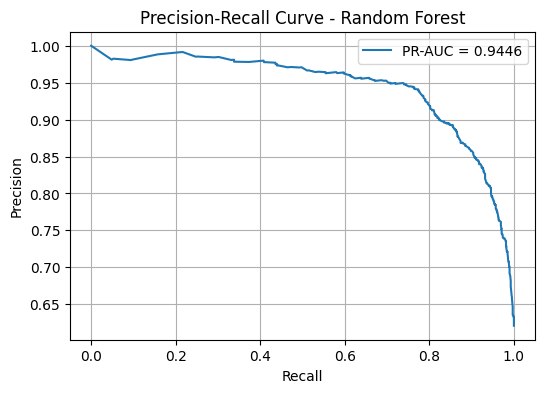

In [14]:
precision, recall, thresholds = precision_recall_curve(y_test, baseline_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,4))

plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")

plt.legend()
plt.grid(True)

plt.show()

# Hyperparameter Optimization
Random Forest 모델의 성능 향상을 위해 하이퍼파라미터 튜닝을 수행한다.

## 13. Recall 중심 Random Forest 모델 정의
클래스 불균형을 고려하여 class_weight를 적용한다.

In [15]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

## 14. Hyperparameter Search 범위 설정
RandomizedSearchCV에서 탐색할 파라미터 범위를 정의한다.

In [16]:
param_dist = {
    'n_estimators': [200,300,500,700],
    'max_depth': [None,5,10,15,20],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,8],
    'max_features': ['sqrt','log2',None],
    'class_weight': ['balanced','balanced_subsample']
}

## 15. RandomizedSearchCV 실행
Recall을 기준으로 최적의 하이퍼파라미터를 탐색한다.

In [17]:
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV Recall:", random_search.best_score_)

Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20, 'class_weight': 'balanced_subsample'}
Best CV Recall: 0.8846105191986826


## 16. Best Model 저장
튜닝을 통해 얻은 최적 모델을 저장한다.

In [18]:
best_model = random_search.best_estimator_

## 17. Tuned 모델 예측
최적 모델을 사용하여 테스트 데이터를 예측한다.

In [19]:
tuned_pred = best_model.predict(X_test)
tuned_pred_proba = best_model.predict_proba(X_test)[:,1]

## 18. Tuned 모델 평가
튜닝된 모델의 성능을 평가한다.

In [20]:
print(classification_report(y_test, tuned_pred))
print(confusion_matrix(y_test, tuned_pred))

print("Precision:", precision_score(y_test, tuned_pred))
print("Recall:", recall_score(y_test, tuned_pred))
print("F1:", f1_score(y_test, tuned_pred))
print("ROC-AUC:", roc_auc_score(y_test, tuned_pred_proba))
print("PR-AUC:", average_precision_score(y_test, tuned_pred_proba))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79       654
           1       0.87      0.88      0.88      1071

    accuracy                           0.84      1725
   macro avg       0.83      0.83      0.83      1725
weighted avg       0.84      0.84      0.84      1725

[[509 145]
 [125 946]]
Precision: 0.8670944087992667
Recall: 0.8832866479925303
F1: 0.8751156336725254
ROC-AUC: 0.9124792628570286
PR-AUC: 0.9391024779155169


# Threshold Tuning
Recall 향상을 위해 prediction threshold를 조정한다.

## 19. Threshold 성능 비교
여러 threshold 값에 대해 precision / recall / f1-score를 비교한다.

In [21]:
threshold_list = np.arange(0.9, 0.05, -0.05)

threshold_result = []

for threshold in threshold_list:

    pred_threshold = (tuned_pred_proba >= threshold).astype(int)

    threshold_result.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold),
        "f1": f1_score(y_test, pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_result)

threshold_df

,threshold,precision,recall,f1
0,0.90,0.966038,0.478058,0.639600
1,0.85,0.962006,0.591036,0.732215
2,0.80,0.953704,0.673203,0.789272
3,0.75,0.944910,0.736695,0.827912
4,0.70,0.929688,0.777778,0.846975
5,0.65,0.918067,0.816060,0.864063
6,0.60,0.902806,0.841270,0.870952
7,0.55,0.881679,0.862745,0.872109
8,0.50,0.867094,0.883287,0.875116
9,0.45,0.844873,0.900093,0.871609


## 20. Threshold별 성능 시각화
threshold 변화에 따라 Precision, Recall, F1-score가 어떻게 변하는지 확인한다.

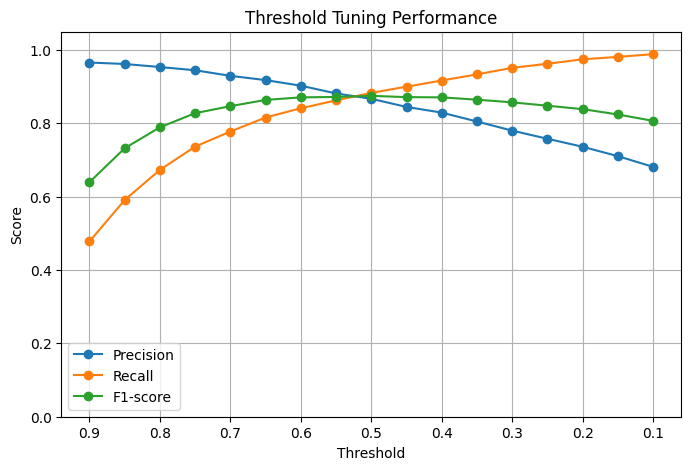

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['f1'],
    marker='o',
    label='F1-score'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning Performance')
plt.gca().invert_xaxis()  # threshold가 낮아지는 방향으로 보기 쉽게
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

## 21. Precision-Recall Trade-off 시각화
threshold를 낮출수록 Recall이 증가하고 Precision이 감소하는 패턴을 확인한다.

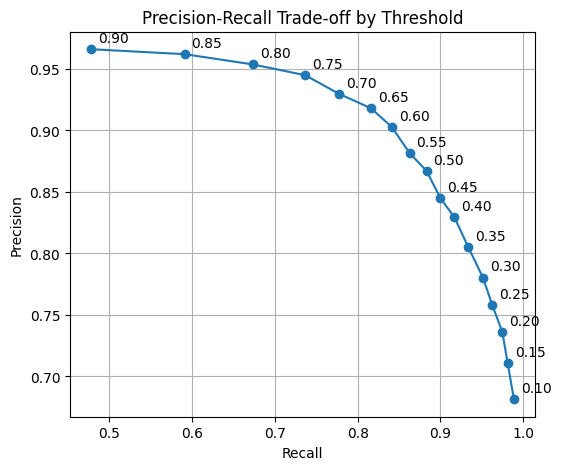

In [23]:
plt.figure(figsize=(6, 5))

plt.plot(
    threshold_df['recall'],
    threshold_df['precision'],
    marker='o'
)

for _, row in threshold_df.iterrows():
    plt.annotate(
        f"{row['threshold']:.2f}",
        (row['recall'], row['precision']),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off by Threshold')
plt.grid(True)
plt.show()

## 22. 최종 Threshold 적용
선택한 threshold를 적용하여 최종 모델 성능을 평가한다.

In [24]:
best_threshold = 0.80

pred_final = (tuned_pred_proba >= best_threshold).astype(int)

print(classification_report(y_test, pred_final))
print(confusion_matrix(y_test, pred_final))

              precision    recall  f1-score   support

           0       0.64      0.95      0.76       654
           1       0.95      0.67      0.79      1071

    accuracy                           0.78      1725
   macro avg       0.80      0.81      0.78      1725
weighted avg       0.83      0.78      0.78      1725

[[619  35]
 [350 721]]


# Feature Importance

## 23. Feature Importance 추출
튜닝된 Random Forest 모델의 변수 중요도를 확인한다.

In [25]:
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
7,total_watch_time,0.335221
12,avg_progress,0.123838
0,age,0.120493
11,days_since_last_watch,0.071773
2,monthly_spend,0.058824
4,subscription_tenure_days,0.047717
1,plan_tier,0.038858
8,avg_watch_time,0.037778
14,download_ratio,0.034934
15,avg_rating,0.033603


## 24. Feature Importance 시각화

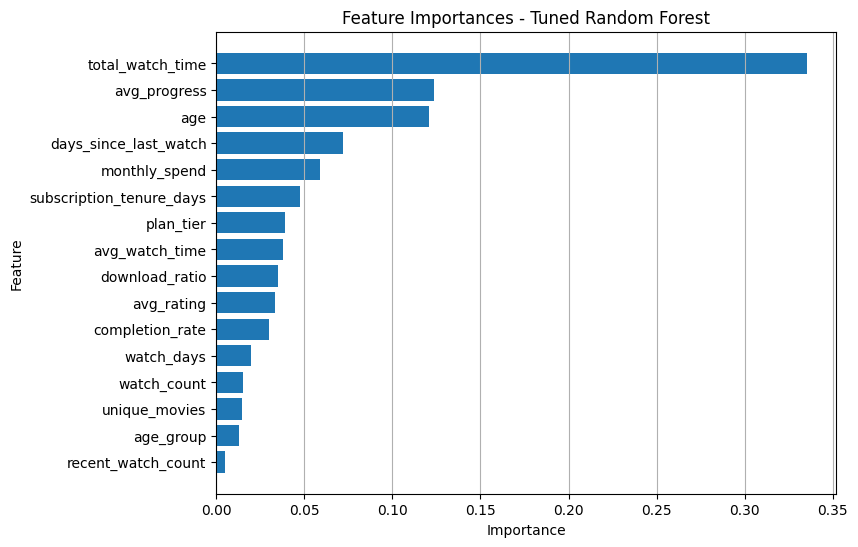

In [28]:
plt.figure(figsize=(8, 6))

plot_df = feature_importance_df.sort_values(by='importance', ascending=True)

plt.barh(plot_df['feature'], plot_df['importance'])

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances - Tuned Random Forest')
plt.grid(axis='x')
plt.show()